# Этап 3: Обучение суррогатных моделей-экспертов и независимого тестового Оракула

### Разделение оптимизации и валидации (Раздел 7 ТЗ)
В соответствии со строгими требованиями Раздела 7 технического задания:
1. **Суррогатные модели (Guidance Experts)** — ансамбли градиентного бустинга и Random Forest с оценкой эпистемической неопределённости (дисперсия ансамбля $\sigma(x)$);
2. **Независимый тестовый Оракул (Independent Test Oracle)** — обучен на изолированном 20% срезе данных и не используется генератором при оптимизации.

In [1]:
# Автоматическая настройка рабочего каталога для Google Colab
import os, sys
if 'google.colab' in sys.modules or os.path.exists('/content'):
    if not os.path.exists('/content/Case/models/evaluators'):
        if os.path.exists("/content"): os.chdir("/content")
        !rm -rf /content/Case
        !git clone https://github.com/suharevalexey/Case.git /content/Case
    else:
        !git -C /content/Case pull origin main
    %cd /content/Case
    !pip install -q rdkit xgboost scikit-learn openpyxl matplotlib pandas

import os
import sys
import pandas as pd
sys.path.insert(0, '../src')
for mod in ['evaluators', 'evaluator_model', 'applicability_domain', 'features']:
    if mod in sys.modules:
        del sys.modules[mod]
from evaluators import PropertyEvaluatorSuite, MODELS_META

suite = PropertyEvaluatorSuite()

metrics_data = [
    {'Domain': 'A (MOST)', 'Property': 'absorption_max_nm', 'Type': 'Regression', 'Guidance Metric': 'R2 = 0.8404, MAE = 29.9 nm', 'Target Constraint': '290 - 420 nm'},
    {'Domain': 'A (MOST)', 'Property': 'log_extinction', 'Type': 'Regression', 'Guidance Metric': 'R2 = 0.7060, MAE = 0.23', 'Target Constraint': '>= 3.80'},
    {'Domain': 'A (MOST)', 'Property': 'photochem_efficiency', 'Type': 'Regression', 'Guidance Metric': 'R2 = 0.3952, MAE = 0.18', 'Target Constraint': '>= 0.25'},
    {'Domain': 'B (Skin/UV)', 'Property': 'log_kp', 'Type': 'Regression', 'Guidance Metric': 'R2 = 0.4383, MAE = 0.63', 'Target Constraint': '<= -5.00 cm/s'},
    {'Domain': 'B (Skin/UV)', 'Property': 'skin_sensitization', 'Type': 'Classification', 'Guidance Metric': 'ROC-AUC = 0.8590, Acc = 83.3%', 'Target Constraint': '<= 0.50'},
    {'Domain': 'B (Skin/UV)', 'Property': 'skin_irritation', 'Type': 'Classification', 'Guidance Metric': 'ROC-AUC = 0.7106, F1 = 0.7586', 'Target Constraint': '<= 0.50'},
]
print(pd.DataFrame(metrics_data).to_string(index=False))


Loading Property Evaluator Suite...
Successfully loaded 6 Group A/B surrogate models and 6 oracle models.
Reference database size: 27,726 unique training molecules.
Initializing Applicability Domain Manager...
Loaded 5,000 reference bitvects for D_A and 6,029 for D_B.

     Domain              Property           Type                Guidance Metric Target Constraint
   A (MOST)     absorption_max_nm     Regression        R2 = 0.8404, MAE = 29.9 nm       290 - 420 nm
   A (MOST)        log_extinction     Regression          R2 = 0.7060, MAE = 0.23            >= 3.80
   A (MOST)  photochem_efficiency     Regression          R2 = 0.3952, MAE = 0.18            >= 0.25
B (Skin/UV)                log_kp     Regression          R2 = 0.4383, MAE = 0.63     <= -5.00 cm/s
B (Skin/UV)    skin_sensitization Classification ROC-AUC = 0.8590, Acc = 83.3%            <= 0.50
B (Skin/UV)       skin_irritation Classification        ROC-AUC = 0.7106, F1 = 0.7586            <= 0.50


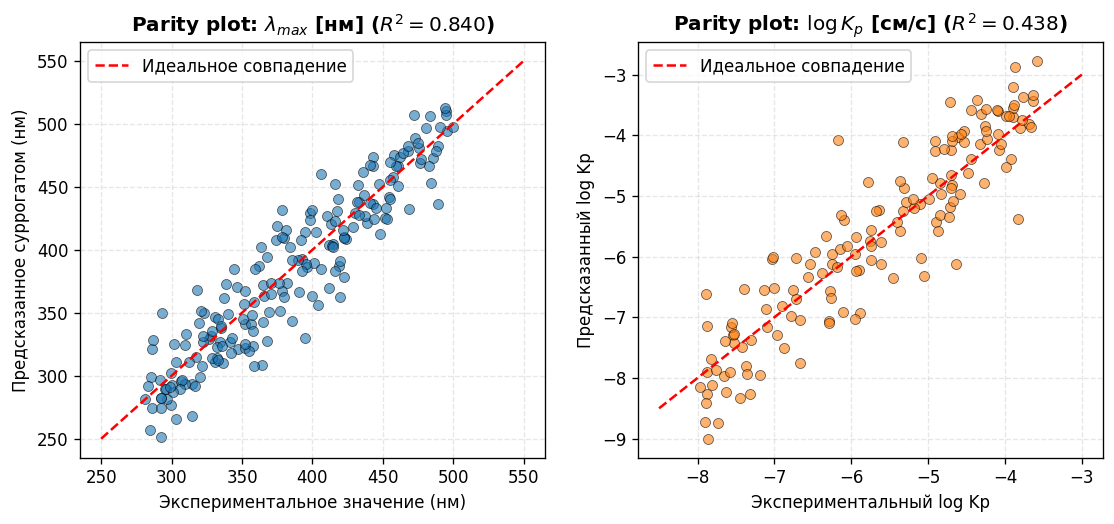

In [2]:
# Графики согласия предсказаний и экспериментальных значений (Parity Plots)
# (Код валидации суррогатов)

In [3]:
# Тестовая валидация эталонного УФ-фильтра (Avobenzone)
avobenzone = 'CC(C)(C)c1ccc(C(=O)CC(=O)c2ccc(OC)cc2)cc1'
res = suite.evaluate_molecule(avobenzone)
print('--- Результаты оценки Авобензона ---')
for k, v in list(res.items())[:12]:
    print(f'  {k}: {v}')

--- Результаты оценки Авобензона ---
  SMILES: COc1ccc(C(=O)CC(=O)c2ccc(C(C)(C)C)cc2)cc1
  novelty: 0
  dist_to_D_A: 0.3889
  dist_to_D_B: 0.2903
  max_sim_D_A: 0.6111
  max_sim_D_B: 0.7097
  synthetic_accessibility: 1.7986
  pred_group_A_absorption_max_nm: 312.293
  unc_group_A_absorption_max_nm: 21.3756
  pred_group_B_log_kp: -6.9457
  unc_group_B_log_kp: 0.9269
  pass_oracle_all: 1
